# NHS Sentiment Analysis — Stage 4 & 5: Feature Extraction + Classification
**Student:** Uday Kiran Pappu | **Module:** 7150CEM

> Self-contained — runs standalone or chained after earlier stages.

In [1]:
# ============================================================
# NHS SENTIMENT ANALYSIS — STAGE 4 & 5
# Feature Extraction + Sentiment Classification
# Fully self-contained — no external .py file dependencies
# Student: Uday Kiran Pappu | Module: 7150CEM
# ============================================================

In [2]:
# ── CELL 1: Imports ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re, warnings, os, nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
for pkg in ['punkt','punkt_tab','stopwords','wordnet','vader_lexicon']:
    nltk.download(pkg, quiet=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
COLORS = {
    'positive': '#2ecc71',
    'negative': '#e74c3c',
    'neutral':  '#3498db',
}
OUTPUT_DIR = "/kaggle/working" if os.path.exists("/kaggle/working") else "."

In [3]:
# ── CELL 2: Self-contained data loader ───────────────────────
def generate_synthetic_nhs_data(n=5000, seed=42):
    rng = np.random.default_rng(seed)
    positive_reviews = [
        "The staff were incredibly kind and professional throughout my stay.",
        "Excellent care provided by all nurses and doctors. Very impressed.",
        "My treatment was handled efficiently and with great compassion.",
        "The consultant explained everything clearly. Outstanding service.",
        "Clean wards, friendly staff and fast treatment. Highly satisfied.",
        "I felt completely cared for. The NHS is truly remarkable.",
        "Brilliant experience at the outpatient clinic. Very professional.",
        "Staff were attentive, warm and highly skilled. Thank you NHS.",
        "The nurses were amazing, always checking on me day and night.",
        "Quick diagnosis and treatment. Felt safe and well looked after.",
        "Great communication throughout. My recovery was smooth thanks to them.",
        "The physiotherapy team were exceptional. Really helped my recovery.",
        "Friendly and efficient A&E team. Treated quickly and with care.",
        "I was nervous but staff made me feel completely at ease.",
        "Wonderful midwives during my labour. Felt so supported throughout.",
        "The ward was spotlessly clean and the food was surprisingly good.",
        "Staff went above and beyond during my emergency admission.",
        "Everything was explained in plain English. Felt fully informed.",
    ]
    negative_reviews = [
        "Waited over 6 hours in A&E with no updates at all. Unacceptable.",
        "Appointment was cancelled twice with no explanation or rescheduling.",
        "Staff seemed rushed and did not explain my diagnosis properly.",
        "The ward was understaffed and I had to wait too long for pain relief.",
        "Discharge process was chaotic. Nobody told me what medications to take.",
        "Long waiting times and poor communication from admin staff.",
        "My referral was lost and I had to start the whole process again.",
        "I had to chase the GP several times just to get a basic test result.",
        "Felt like just a number. No personalised care whatsoever.",
        "Waited 3 weeks for an urgent referral. Very worrying experience.",
        "The receptionist was rude and dismissive when I called to book.",
        "My surgery was delayed twice with very little communication.",
        "The follow-up appointment system is completely broken and frustrating.",
        "Medication was incorrect on discharge. Dangerous and inexcusable.",
        "Staff ignored my call button for over 45 minutes.",
    ]
    neutral_reviews = [
        "Standard treatment. Nothing particularly good or bad to report.",
        "The appointment was on time and staff were professional.",
        "Average experience. Received the treatment needed without issues.",
        "Routine check-up completed. Waiting time was acceptable.",
        "Care was satisfactory. Nothing stood out either way.",
        "Mixed experience. Some staff were great, others less so.",
        "The treatment worked but the process could have been smoother.",
        "Acceptable service. Would have preferred clearer information.",
    ]
    organisations = [
        "Manchester University NHS Foundation Trust",
        "Leeds Teaching Hospitals NHS Trust",
        "King's College Hospital NHS Foundation Trust",
        "University College London Hospitals NHS Foundation Trust",
        "Sheffield Teaching Hospitals NHS Foundation Trust",
        "Oxford University Hospitals NHS Foundation Trust",
    ]
    service_types  = ['A&E','Outpatient','Inpatient','GP Practice',
                      'Maternity','Mental Health','Physiotherapy','Surgery']
    platforms      = ['NHS.uk','Reddit','Twitter/X','Facebook Group']
    platform_w     = [0.55, 0.20, 0.15, 0.10]
    years          = list(range(2018, 2026))
    year_w         = [0.08, 0.09, 0.10, 0.11, 0.14, 0.16, 0.16, 0.16]
    sentiments     = ['positive','negative','neutral']
    sent_w         = [0.52, 0.34, 0.14]
    records = []
    for i in range(n):
        sentiment = str(rng.choice(sentiments, p=sent_w))
        if sentiment == 'positive':
            text = str(rng.choice(positive_reviews))
            if rng.random() > 0.6:
                text += ' ' + str(rng.choice(['Would definitely recommend.',
                    'Thank you to all the team.','Five stars without hesitation.']))
        elif sentiment == 'negative':
            text = str(rng.choice(negative_reviews))
            if rng.random() > 0.6:
                text += ' ' + str(rng.choice(['Needs urgent improvement.',
                    'Really disappointed.','Would not recommend.']))
        else:
            text = str(rng.choice(neutral_reviews))
        rating = int({'positive': rng.integers(4,6),
                      'negative': rng.integers(1,3),
                      'neutral':  rng.integers(2,5)}[sentiment])
        year  = int(rng.choice(years, p=year_w))
        month = int(rng.integers(1,13))
        records.append({
            'review_id':       i+1,
            'date':            f'{year}-{month:02d}-{int(rng.integers(1,29)):02d}',
            'year':            year,
            'month':           month,
            'organisation':    str(rng.choice(organisations)),
            'service_type':    str(rng.choice(service_types)),
            'platform':        str(rng.choice(platforms, p=platform_w)),
            'review_text':     text,
            'rating':          rating,
            'sentiment_label': sentiment,
            'word_count':      len(text.split()),
        })
    return pd.DataFrame(records)


def run_preprocessing(df_raw):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english')) - {
        'not','no','never','nothing','neither','nobody','nor','cannot'
    }
    def clean_text(t):
        t = str(t).lower()
        t = re.sub(r'<[^>]+>|http\S+|www\S+|@\w+|#\w+|\d+', ' ', t)
        t = re.sub(r'[^\w\s]', ' ', t)
        return re.sub(r'\s+', ' ', t).strip()
    def preprocess(t):
        tokens = word_tokenize(clean_text(t))
        tokens = [tok for tok in tokens if tok not in stop_words and len(tok) > 2]
        return ' '.join(lemmatizer.lemmatize(tok) for tok in tokens)
    tc = next((c for c in ['review_text','text','review','comment','feedback']
               if c in df_raw.columns), df_raw.columns[0])
    df_raw = df_raw.dropna(subset=[tc]).drop_duplicates(subset=[tc])
    df_raw = df_raw[df_raw[tc].str.len() >= 10].copy()
    df_raw['cleaned_text']   = df_raw[tc].apply(clean_text)
    df_raw['processed_text'] = df_raw[tc].apply(preprocess)
    df_raw['word_count']     = df_raw[tc].str.split().str.len()
    df_raw['token_count']    = df_raw['processed_text'].str.split().str.len()
    return df_raw, tc


# Load data — try Stage 1&2 CSV first, then input CSVs, then synthetic
df = None
clean_path = f"{OUTPUT_DIR}/nhs_clean_data.csv"

if os.path.exists(clean_path):
    df = pd.read_csv(clean_path)
    print(f"✅ Loaded Stage 1&2 output: {df.shape}")

if df is None and os.path.exists("/kaggle/input"):
    best_score, best_path = -1, None
    for root, _, files in os.walk("/kaggle/input"):
        for fname in files:
            if not fname.endswith('.csv'): continue
            fpath = os.path.join(root, fname)
            try:
                tmp = pd.read_csv(fpath, nrows=20)
                if len(tmp) < 5: continue
                score = len(tmp.columns) * 2
                sc = tmp.select_dtypes(include='object')
                if len(sc.columns):
                    score += int(sc.apply(lambda c: c.str.len().mean()).max() // 5)
                if score > best_score:
                    best_score, best_path = score, fpath
            except Exception:
                continue
    if best_path:
        raw = pd.read_csv(best_path)
        if len(raw) >= 10:
            df, _ = run_preprocessing(raw)
            print(f"✅ Loaded from /kaggle/input: {df.shape}")

if df is None:
    raw = generate_synthetic_nhs_data(n=5000)
    df, _ = run_preprocessing(raw)
    print(f"✅ Using synthetic NHS data: {df.shape}")

# Resolve column names
proc_col = 'processed_text' if 'processed_text' in df.columns else \
           next((c for c in ['review_text','text','review'] if c in df.columns), df.columns[0])
sent_col = next(
    (c for c in ['sentiment_label','ml_predicted_sentiment','sentiment','label']
     if c in df.columns), None
)
df[proc_col] = df[proc_col].fillna('').astype(str)
print(f"   proc_col={proc_col} | sent_col={sent_col}")

✅ Using synthetic NHS data: (140, 14)
   proc_col=processed_text | sent_col=sentiment_label



STAGE 5A — LEXICON-BASED SENTIMENT
VADER distribution:
vader_sentiment
positive    89
negative    43
neutral      8
Name: count, dtype: int64

TextBlob distribution:
textblob_sentiment
positive    64
neutral     42
negative    34
Name: count, dtype: int64


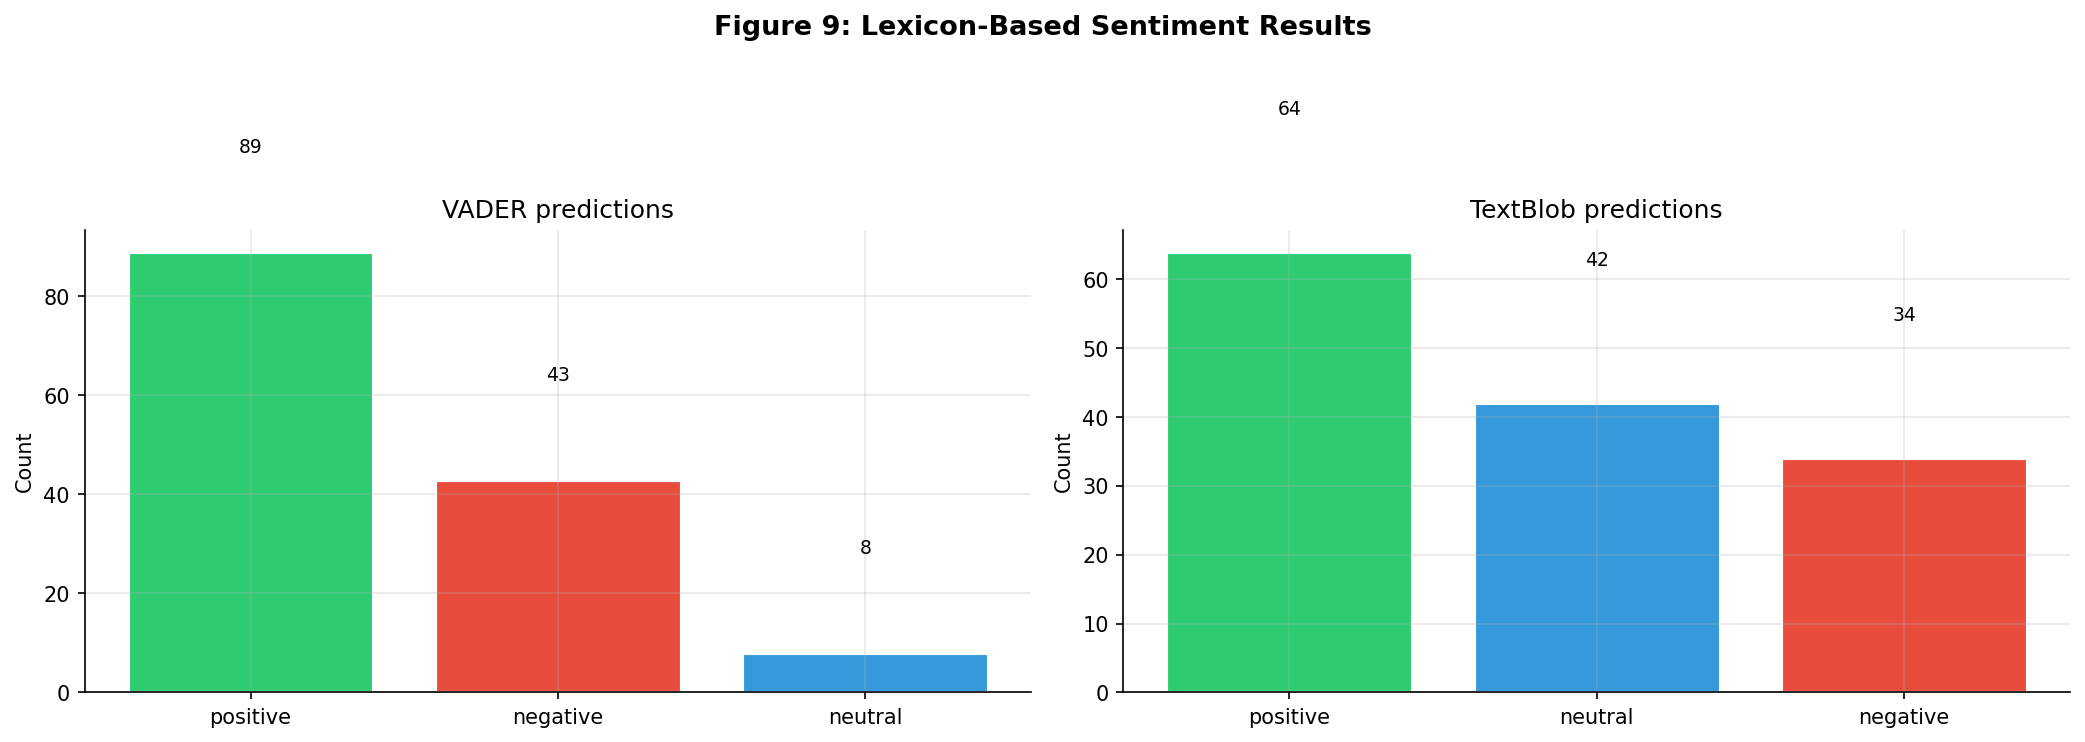

✅ Figure 9 saved.


In [4]:
# ── CELL 3: VADER + TextBlob ──────────────────────────────────
print("\n" + "="*55)
print("STAGE 5A — LEXICON-BASED SENTIMENT")
print("="*55)

sia = SentimentIntensityAnalyzer()

def vader_label(text):
    s = sia.polarity_scores(str(text))['compound']
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

def textblob_label(text):
    s = TextBlob(str(text)).sentiment.polarity
    return 'positive' if s > 0.1 else ('negative' if s < -0.1 else 'neutral')

df['vader_compound']     = df[proc_col].apply(lambda t: sia.polarity_scores(str(t))['compound'])
df['textblob_polarity']  = df[proc_col].apply(lambda t: TextBlob(str(t)).sentiment.polarity)
df['vader_sentiment']    = df[proc_col].apply(vader_label)
df['textblob_sentiment'] = df[proc_col].apply(textblob_label)

print("VADER distribution:")
print(df['vader_sentiment'].value_counts())
print("\nTextBlob distribution:")
print(df['textblob_sentiment'].value_counts())

# Figure 9: Lexicon results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 9: Lexicon-Based Sentiment Results',
             fontsize=13, fontweight='bold')
for ax, col, title in zip(axes,
                           ['vader_sentiment','textblob_sentiment'],
                           ['VADER','TextBlob']):
    counts  = df[col].value_counts()
    palette = [COLORS.get(s,'#95a5a6') for s in counts.index]
    bars = ax.bar(counts.index, counts.values, color=palette,
                  edgecolor='white', linewidth=1.5)
    ax.set_title(f'{title} predictions')
    ax.set_ylabel('Count')
    for b, v in zip(bars, counts.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+20,
                f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig9_lexicon_results.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("✅ Figure 9 saved.")

In [5]:
# ── CELL 4: TF-IDF Feature Extraction ────────────────────────
print("\n" + "="*55)
print("STAGE 4 — TF-IDF FEATURE EXTRACTION")
print("="*55)

tfidf = TfidfVectorizer(
    max_features=10000, ngram_range=(1,2),
    min_df=3, max_df=0.90, sublinear_tf=True
)
X_tfidf = tfidf.fit_transform(df[proc_col].fillna(''))
feature_names = np.array(tfidf.get_feature_names_out())
print(f"TF-IDF matrix: {X_tfidf.shape[0]:,} docs × {X_tfidf.shape[1]:,} features")
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).flatten()
top20 = mean_tfidf.argsort()[::-1][:20]
print(f"Top 20 terms: {list(feature_names[top20])}")


STAGE 4 — TF-IDF FEATURE EXTRACTION
TF-IDF matrix: 140 docs × 335 features
Top 20 terms: ['staff', 'would', 'recommend', 'team', 'treatment', 'thank', 'really', 'without', 'felt', 'urgent', 'not', 'thank team', 'care', 'definitely', 'definitely recommend', 'would definitely', 'without hesitation', 'star', 'star without', 'hesitation']



STAGE 5B — ML CLASSIFICATION MODELS
Classes: ['negative', 'neutral', 'positive']
Train: 112 | Test: 28

  Training: Logistic Regression...
    Accuracy=0.8929 | F1=0.6167 | CV=0.6485±0.0071

  Training: Naive Bayes...
    Accuracy=0.9286 | F1=0.6418 | CV=0.6485±0.0071

  Training: Linear SVM...
    Accuracy=0.8929 | F1=0.6167 | CV=0.7179±0.1412

  Training: Random Forest...
    Accuracy=0.9286 | F1=0.8621 | CV=0.7012±0.0913


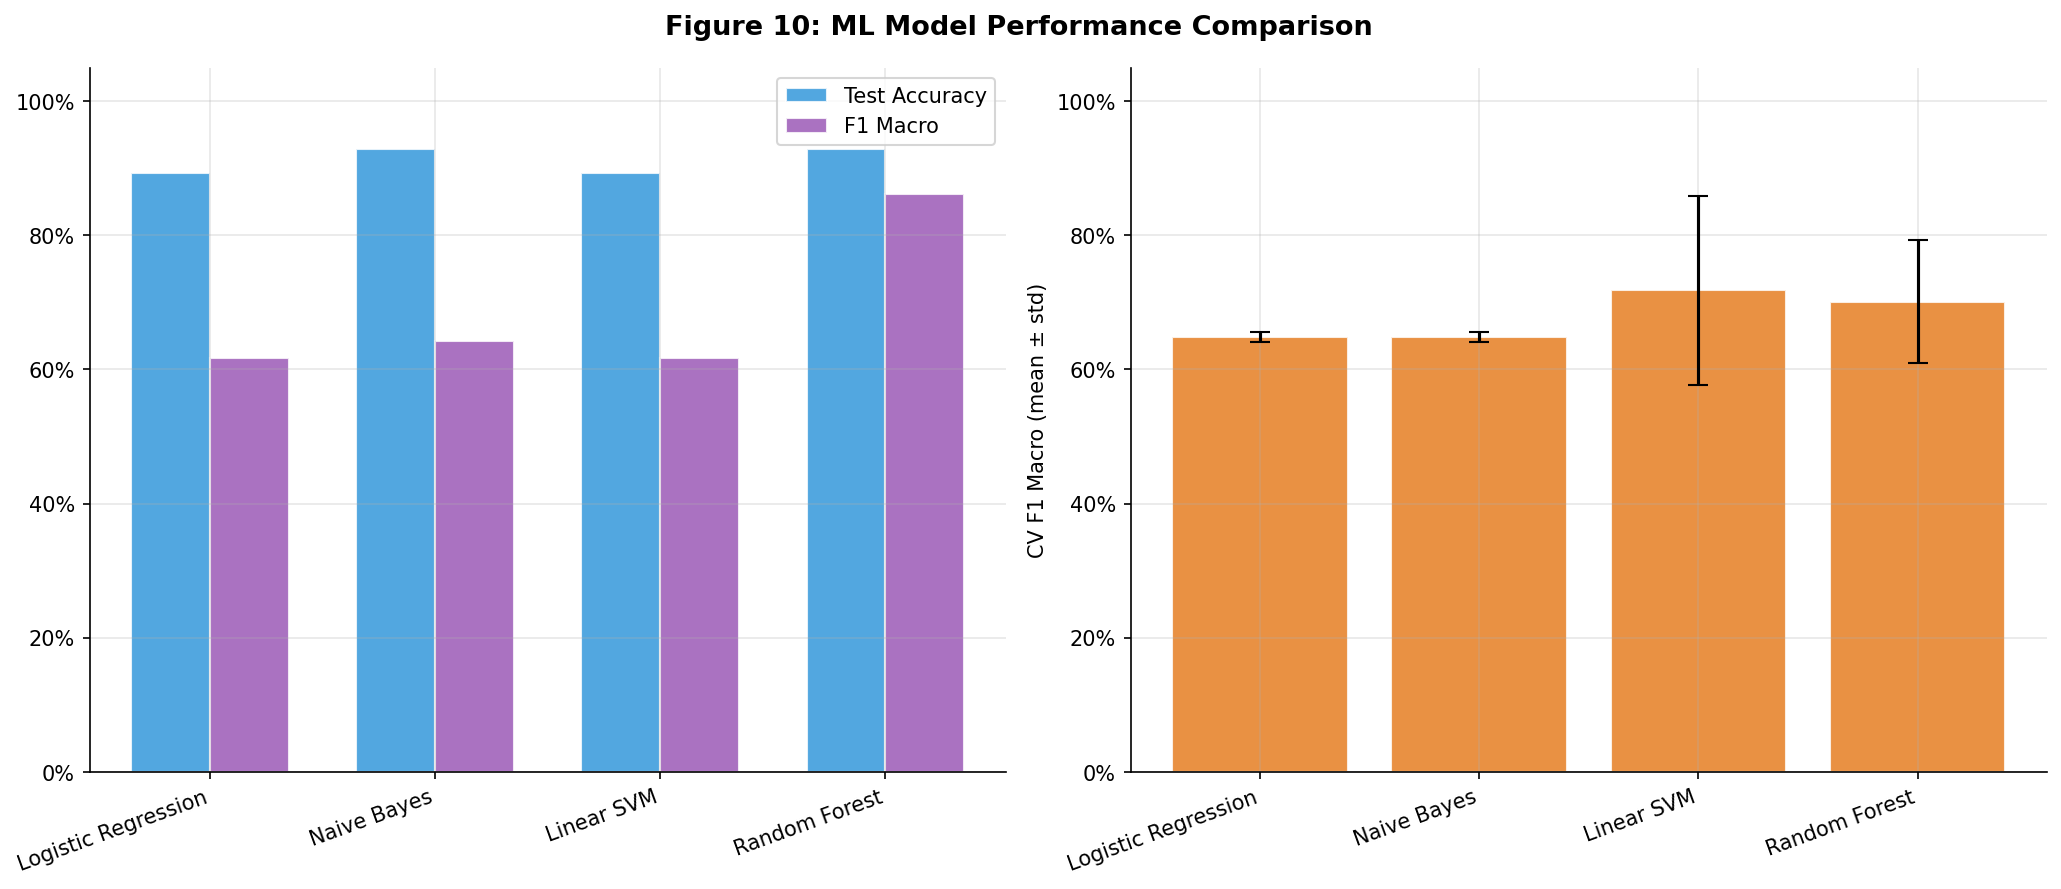

✅ Figure 10 saved.

🏆 Best model: Random Forest  F1=0.8621
              precision    recall  f1-score   support

    negative       1.00      0.92      0.96        12
     neutral       0.50      1.00      0.67         2
    positive       1.00      0.93      0.96        14

    accuracy                           0.93        28
   macro avg       0.83      0.95      0.86        28
weighted avg       0.96      0.93      0.94        28



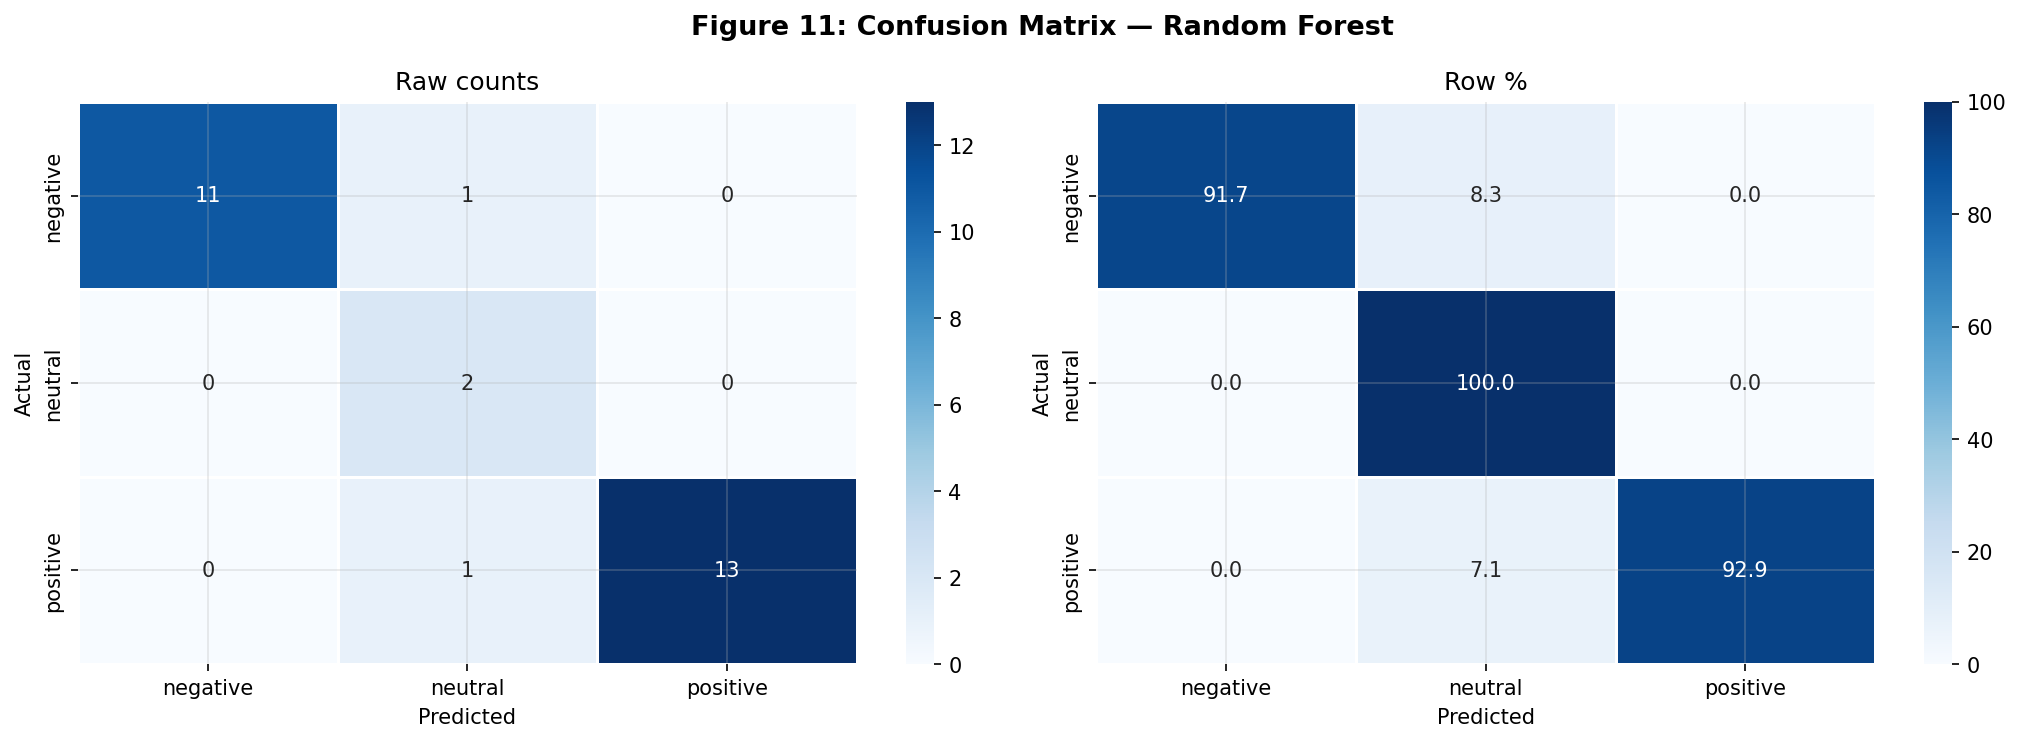

✅ Figure 11 saved.


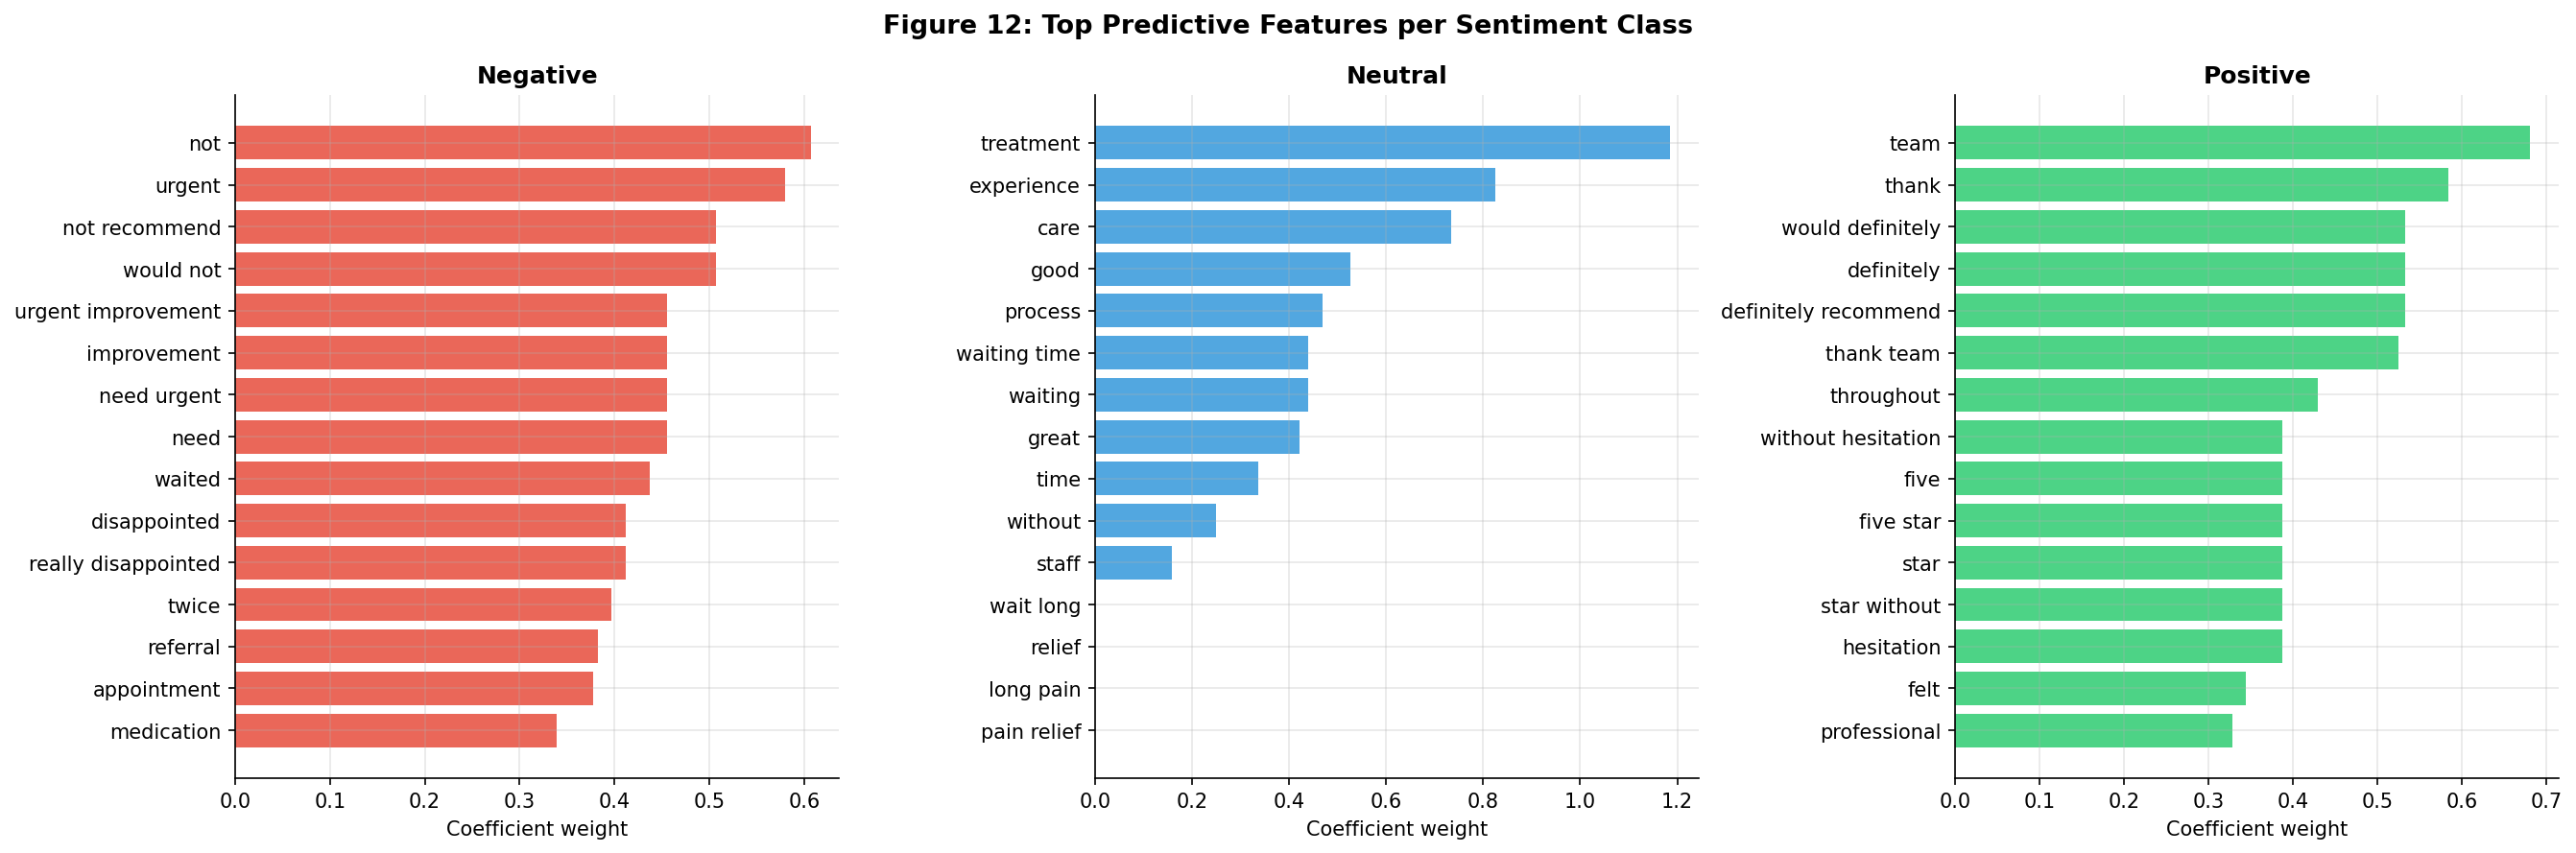

✅ Figure 12 saved.


In [6]:
# ── CELL 5: ML Classification ─────────────────────────────────
print("\n" + "="*55)
print("STAGE 5B — ML CLASSIFICATION MODELS")
print("="*55)

results = {}

if sent_col and df[sent_col].nunique() >= 2:
    le = LabelEncoder()
    y  = le.fit_transform(df[sent_col])
    print(f"Classes: {list(le.classes_)}")

    X_train, X_test, y_train, y_test = train_test_split(
        X_tfidf, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
        'Naive Bayes':         MultinomialNB(alpha=0.5),
        'Linear SVM':          LinearSVC(max_iter=2000, C=1.0, random_state=42),
        'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, model in models.items():
        print(f"\n  Training: {name}...")
        model.fit(X_train, y_train)
        y_pred   = model.predict(X_test)
        cv_sc    = cross_val_score(model, X_train, y_train,
                                   cv=cv, scoring='f1_macro', n_jobs=-1)
        results[name] = {
            'model':       model,
            'y_pred':      y_pred,
            'accuracy':    accuracy_score(y_test, y_pred),
            'f1_macro':    f1_score(y_test, y_pred, average='macro'),
            'f1_weighted': f1_score(y_test, y_pred, average='weighted'),
            'cv_mean':     cv_sc.mean(),
            'cv_std':      cv_sc.std(),
        }
        print(f"    Accuracy={results[name]['accuracy']:.4f} | F1={results[name]['f1_macro']:.4f} | CV={cv_sc.mean():.4f}±{cv_sc.std():.4f}")

    # ── Figure 10: Model comparison ───────────────────────────
    names = list(results.keys())
    x, w  = np.arange(len(names)), 0.35
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Figure 10: ML Model Performance Comparison',
                 fontsize=13, fontweight='bold')
    axes[0].bar(x-w/2, [results[n]['accuracy']  for n in names], w,
                label='Test Accuracy', color='#3498db', alpha=0.85, edgecolor='white')
    axes[0].bar(x+w/2, [results[n]['f1_macro']  for n in names], w,
                label='F1 Macro',     color='#9b59b6', alpha=0.85, edgecolor='white')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(names, rotation=20, ha='right')
    axes[0].set_ylim(0, 1.05)
    axes[0].legend()
    axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    axes[1].bar(x, [results[n]['cv_mean'] for n in names],
                color='#e67e22', alpha=0.85, edgecolor='white',
                yerr=[results[n]['cv_std'] for n in names], capsize=5)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(names, rotation=20, ha='right')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_ylabel('CV F1 Macro (mean ± std)')
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig10_model_comparison.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Figure 10 saved.")

    # ── Best model ────────────────────────────────────────────
    best_name = max(results, key=lambda n: results[n]['f1_macro'])
    best      = results[best_name]
    print(f"\n🏆 Best model: {best_name}  F1={best['f1_macro']:.4f}")
    print(classification_report(y_test, best['y_pred'], target_names=le.classes_))

    # ── Figure 11: Confusion matrix ───────────────────────────
    cm     = confusion_matrix(y_test, best['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Figure 11: Confusion Matrix — {best_name}',
                 fontsize=13, fontweight='bold')
    for ax, data, fmt, title in zip(
        axes, [cm, cm_pct], ['d','.1f'], ['Raw counts','Row %']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=le.classes_, yticklabels=le.classes_,
                    linewidths=0.5, ax=ax)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig11_confusion_matrix.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Figure 11 saved.")

    # ── Figure 12: Feature importance ────────────────────────
    lr_model  = results['Logistic Regression']['model']
    n_classes = len(le.classes_)
    fig, axes = plt.subplots(1, n_classes, figsize=(6*n_classes, 6))
    if n_classes == 1: axes = [axes]
    fig.suptitle('Figure 12: Top Predictive Features per Sentiment Class',
                 fontsize=13, fontweight='bold')
    for ax, cidx, cname in zip(axes, range(n_classes), le.classes_):
        coefs = lr_model.coef_[cidx] if lr_model.coef_.ndim > 1 else lr_model.coef_[0]
        top15 = np.argsort(coefs)[-15:]
        ax.barh(feature_names[top15], coefs[top15],
                color=COLORS.get(cname,'#95a5a6'), alpha=0.85)
        ax.set_title(cname.capitalize(), fontweight='bold')
        ax.set_xlabel('Coefficient weight')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig12_feature_importance.png',
                bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Figure 12 saved.")

    # Apply best model to full dataset
    df['ml_predicted_sentiment'] = le.inverse_transform(
        results[best_name]['model'].predict(X_tfidf)
    )

    # Save model comparison table
    pd.DataFrame({
        'Model':       names,
        'Accuracy':    [round(results[n]['accuracy'],4)    for n in names],
        'F1_Macro':    [round(results[n]['f1_macro'],4)    for n in names],
        'F1_Weighted': [round(results[n]['f1_weighted'],4) for n in names],
        'CV_F1_Mean':  [round(results[n]['cv_mean'],4)     for n in names],
        'CV_F1_Std':   [round(results[n]['cv_std'],4)      for n in names],
    }).sort_values('F1_Macro', ascending=False).to_csv(
        f'{OUTPUT_DIR}/model_comparison.csv', index=False
    )
else:
    print("⚠️  No sentiment labels found — VADER predictions available above.")

In [7]:
# ── CELL 6: Save enriched dataset ─────────────────────────────
df.to_csv(f'{OUTPUT_DIR}/nhs_with_predictions.csv', index=False)
print(f"\n✅ Dataset with predictions saved → {OUTPUT_DIR}/nhs_with_predictions.csv")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\n🎯 Stages 4 & 5 complete.")


✅ Dataset with predictions saved → /kaggle/working/nhs_with_predictions.csv
   Shape: 140 rows × 19 columns

🎯 Stages 4 & 5 complete.
